# Prueba Final UD3
#### UD3. Aprendizaxe Non Supervisada
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo)


Entrega en el moodle el fichero notebook solución a los siguientes apartados que se te solicitan.

### Dataset: Facebook Live Sellers in Thailand


Este [dataset](https://archive.ics.uci.edu/ml/datasets/Facebook+Live+Sellers+in+Thailand#) contiene 7050 observaciones y doce atributos sobre las páginas de Facebook de 10 vendedores minoristas de moda y cosméticos tailandeses. Publicaciones de diferente naturaleza (video, fotos, estados y enlaces). Las métricas de compromiso consisten en comentarios, acciones y reacciones.

El objetivo del estudio es identificar patrones de grupos a partir de un conjunto de datos para ayudar al comercio minorista de moda y cosméticos a interactuar con los consumidores en Facebook de la manera más eficiente posible.

Cada registro consta de información sobre el momento en que la información de venta se publica en Facebook y las interacciones con los datos.

Lista de atributos:

* status_id
* status_type
* status_published
* num_reactions
* num_comments
* num_shares
* num_likes
* num_loves
* num_wows
* num_hahas
* num_sads
* num_angrys

## 1. Importación del dataset

In [218]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from yellowbrick.cluster import SilhouetteVisualizer
import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [219]:
fb = pd.read_csv('Facebook.csv')
fb

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,7046,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0,NaN,NaN,NaN,NaN
7046,7047,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0,NaN,NaN,NaN,NaN
7047,7048,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN
7048,7049,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0,NaN,NaN,NaN,NaN


In [220]:
fb.describe()

,status_id,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,0.0,0.0,0.0,0.0
mean,3525.500000,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191,NaN,NaN,NaN,NaN
std,2035.304031,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812,NaN,NaN,NaN,NaN
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1763.250000,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,3525.500000,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,5287.750000,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
max,7050.000000,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000,NaN,NaN,NaN,NaN


In [221]:
fb.isnull().sum()

status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64

## 2. EDA&Preprocessing (3 puntos)

Ejercicio 1. Borra las columnas status_id, status_published, Column1, Column2, Column3 y Column4. (0.5 puntos)


In [222]:
fb.drop(columns=['status_id','status_published', 'Column1', 'Column2', 'Column3', 'Column4'], inplace=True)

In [223]:
fb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_type    7050 non-null   object
 1   num_reactions  7050 non-null   int64 
 2   num_comments   7050 non-null   int64 
 3   num_shares     7050 non-null   int64 
 4   num_likes      7050 non-null   int64 
 5   num_loves      7050 non-null   int64 
 6   num_wows       7050 non-null   int64 
 7   num_hahas      7050 non-null   int64 
 8   num_sads       7050 non-null   int64 
 9   num_angrys     7050 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 550.9+ KB


-----

Ejercicio 2. Transforma la columna status_type para que pueda ser útil. No utilices get_dummies. (0.5 puntos)

In [224]:

class_label_encoder = LabelEncoder()
# solo para una col
fb['status_type'] = class_label_encoder.fit_transform(fb['status_type'].values)


------

Ejercicio 3. Muestra gráficamente qué status_type obtiene mayores reacciones. Justifica tu respuesta textualmente. (1 punto)

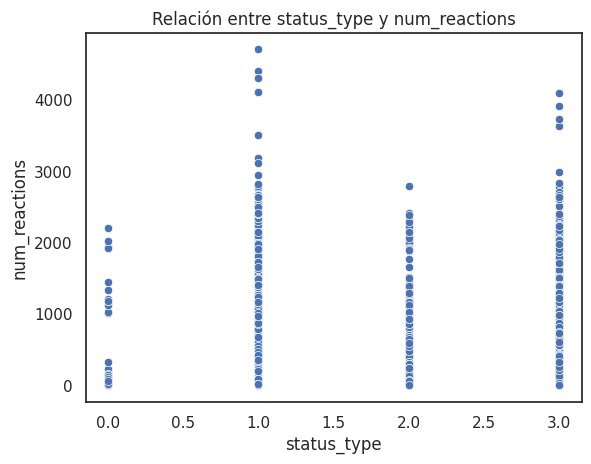

In [225]:
sns.scatterplot(data=fb, x="status_type", y="num_reactions")
plt.title("Relación entre status_type y num_reactions")
plt.xlabel("status_type")
plt.ylabel("num_reactions")
plt.show()          



Los status-type que tienen mayor reacciones pertenecen al 1

-----
Ejercicio 4. Estandariza los datos del dataset. (1 punto)

In [226]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(fb)


## 3. Creación de los modelos, entrenamiento, predicciones y representación gráfica (7 puntos)

----
Ejercicio 5. Crea un modelo K-means, entrénalo y realiza predicciones. (2 puntos)

Buscamos el valor de k óptimo

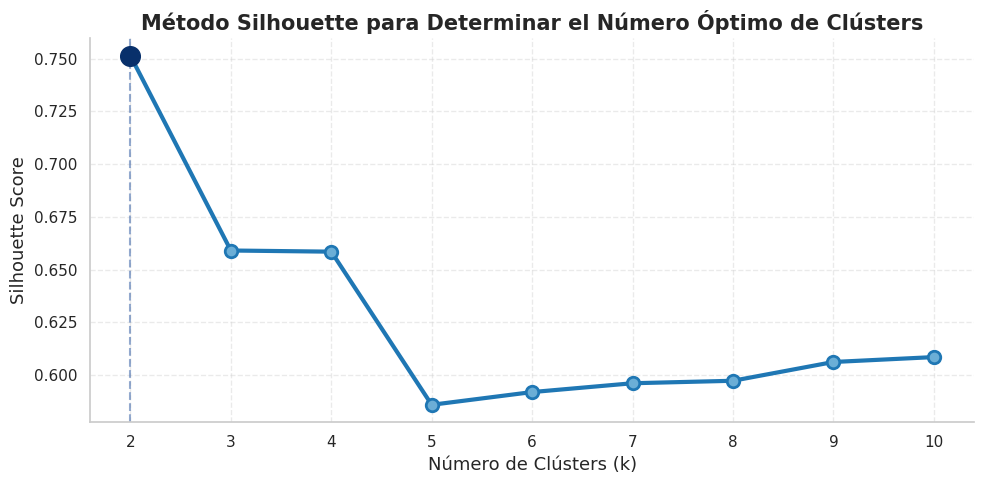

In [227]:
sns.set_style("whitegrid")
K_range = range(2,11)
scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_, metric='euclidean')
    scores.append(score)

scores = np.array(scores)

best_k = list(K_range)[scores.argmax()]
best_score = scores.max()

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    list(K_range),
    scores,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

#esto es para resaltar el mejor k
plt.scatter(best_k, best_score, s=200, color="#08306b", zorder=3)
plt.axvline(best_k, linestyle="--", alpha=0.6)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=13)
plt.title("Método Silhouette para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(list(K_range))
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

Un k=2 me parece demasiado bajo por eso he optado por tomar el valor k = 3

In [228]:
k = 3
kmeans = KMeans(n_clusters=k, n_init='auto', init='k-means++', random_state=30)
kmeans_pred = kmeans.fit_predict(X_scaled)      
centroides = kmeans.cluster_centers_             
fb['Cluster-kmeans'] = kmeans_pred

In [229]:
print("\n--- PERFIL MEDIO DE CADA CLUSTER---")
resultados = fb.groupby('Cluster-kmeans').mean(numeric_only=True)[['status_type','num_reactions', 'num_comments', 'num_shares', 'num_likes', 'num_hahas', 'num_angrys']]
display(resultados)


--- PERFIL MEDIO DE CADA CLUSTER---


,status_type,num_reactions,num_comments,num_shares,num_likes,num_hahas,num_angrys
Cluster-kmeans,,,,,,,
0,2.901235,1355.777778,2899.222222,761.209877,1019.074074,18.086420,3.012346
1,1.532762,204.701828,27.946611,4.862644,201.660087,0.151270,0.014884
2,2.932741,313.763959,1490.019036,241.681472,237.370558,3.185279,0.586294


In [230]:
print(silhouette_score(X_scaled, kmeans_pred))

0.5738885391013882


-----
Ejercicio 6. Crea un modelo de Clustering jerárquico aglomerativo y entrénalo. (2 puntos)

In [231]:

jerarquico = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
etiquetas_jerarquico = jerarquico.fit_predict(X_scaled)

In [232]:
score_jerarquico = silhouette_score(X_scaled, etiquetas_jerarquico)

fb['Cluster_Jerarquico'] = etiquetas_jerarquico

print(f"Nota Silhouette del modelo JERÁRQUICO: {score_jerarquico:.3f}")

Nota Silhouette del modelo JERÁRQUICO: 0.639


-------
Ejercicio 7. Crea un dendrograma que represente el modelo anterior. Interpreta el dendrograma. ¿Cuál sería el número óptimo de clústers?(1 punto)

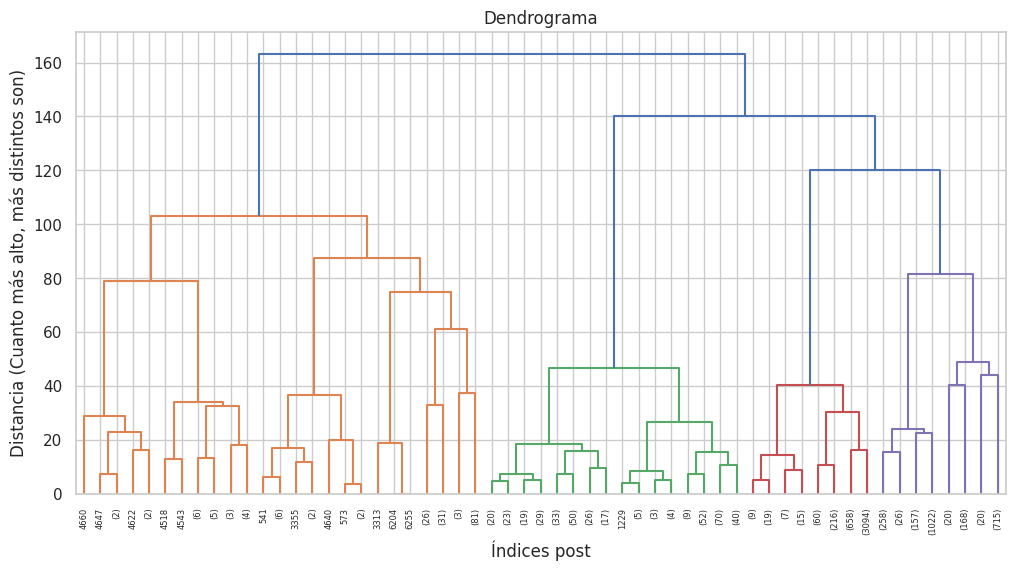

In [233]:

plt.figure(figsize=(12, 6))
plt.title("Dendrograma")
plt.xlabel("Índices post")
plt.ylabel("Distancia (Cuanto más alto, más distintos son)")

matriz_distancias = linkage(X_scaled, method='ward')

dendrogram(matriz_distancias, truncate_mode='level', p=5)
plt.show()


Si trazamos la línea horizontal con el tramo más largo en vertical podría ser el valor 3 clústeres en y=140

In [234]:
print("\n--- PERFIL MEDIO DE CADA CLÚSTER ---")
perfiles = fb.groupby('Cluster_Jerarquico').mean().round(1)
display(perfiles)


--- PERFIL MEDIO DE CADA CLÚSTER ---


,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Cluster-kmeans
Cluster_Jerarquico,,,,,,,,,,,
0,1.7,118.3,127.6,28.3,107.6,9.4,0.6,0.4,0.1,0.1,1.1
1,2.8,827.2,3962.7,513.1,636.8,150.5,23.5,10.5,4.1,1.7,1.1
2,1.6,1757.8,59.1,11.1,1752.1,3.0,2.4,0.2,0.0,0.0,1.0


------- 

Ejercicio 8. Averigua cuál seria el valor óptimo de K para los modelos anteriores. Aplica 2 técnicas diferentes. Extrae conclusiones (2 puntos)

Para obtener el valor óptimo de k podemos usar el método elbow 

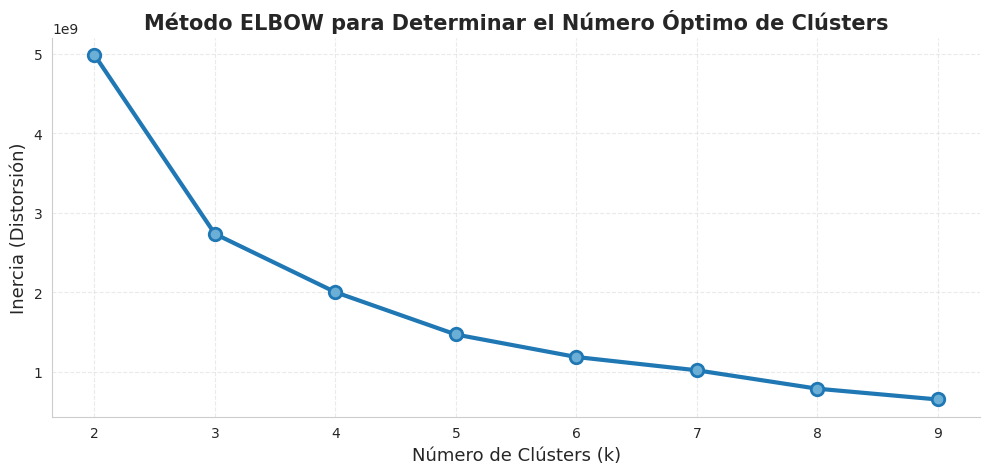

In [246]:

sns.set_style("whitegrid")
distortions = []
K_range = range(2, 10)

for k in K_range:
    kmeanModel = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeanModel.fit(fb)
    distortions.append(kmeanModel.inertia_)

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    K_range,
    distortions,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Inercia (Distorsión)", fontsize=13)
plt.title("Método ELBOW para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(K_range)
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

Dado que el Método del Codo no muestra un punto de inflexión brusco no se puede saber claramente el valor de k, sugeriría el k = 3. 


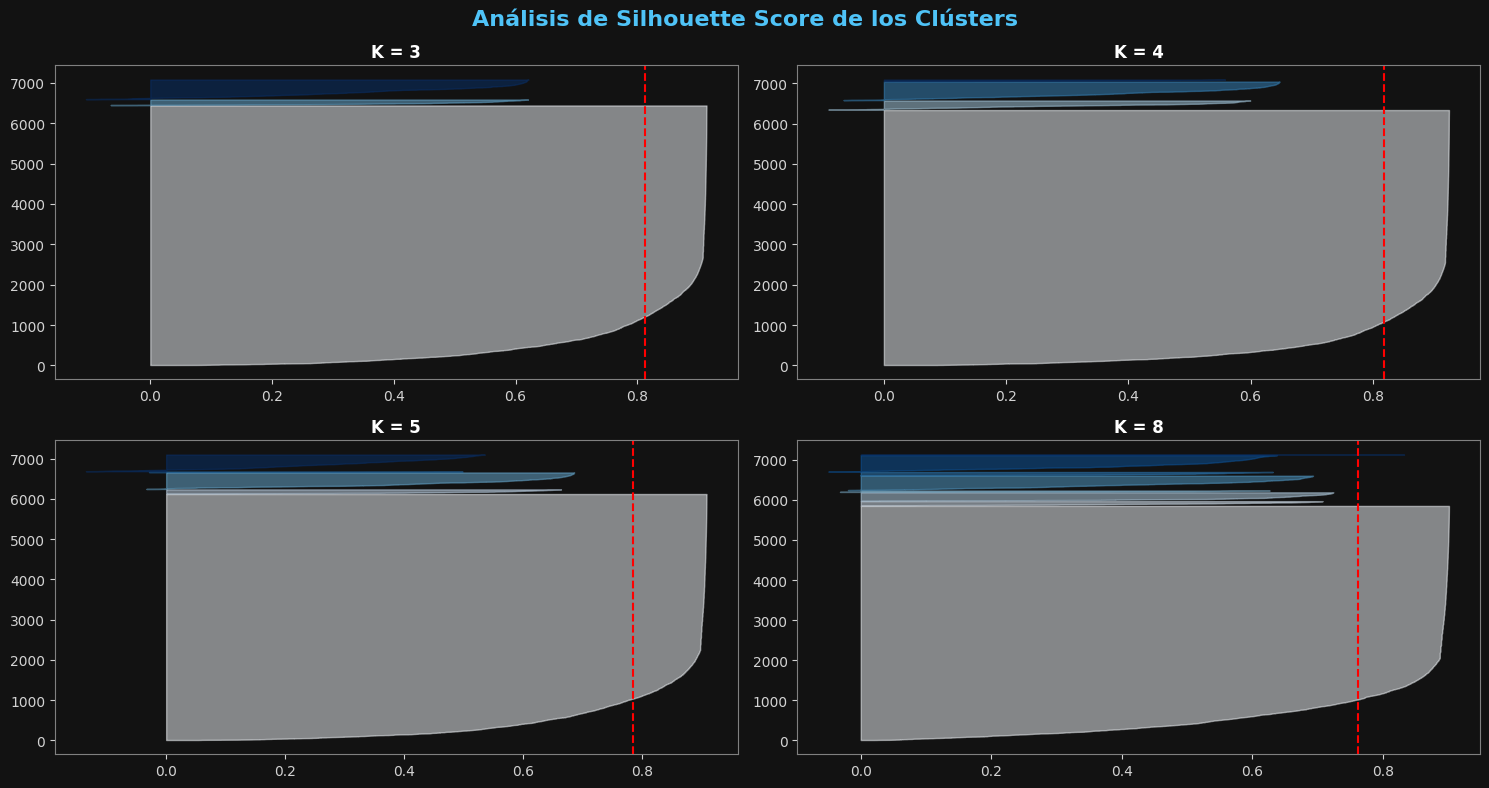

In [245]:

plt.style.use('dark_background')

fig, ax = plt.subplots(2, 2, figsize=(15, 8))
fig.patch.set_facecolor('#121212') 

k_values = [3, 4, 5, 8]

for i, k in enumerate(k_values):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=100, random_state=42)
    
    fila = i // 2
    columna = i % 2
    
    ax[fila][columna].set_facecolor('#121212')
    
    # Al usar 'Blues' sobre fondo negro, los azules resaltarán muchísimo más
    visualizer = SilhouetteVisualizer(km, colors='Blues', ax=ax[fila][columna])
    
    visualizer.fit(fb)
    
    ax[fila][columna].set_title(f"K = {k}", color="white", fontsize=12, weight="bold")
    
    ax[fila][columna].tick_params(colors='lightgray')
    for spine in ax[fila][columna].spines.values():
        spine.set_color('gray')

fig.suptitle("Análisis de Silhouette Score de los Clústers", color="#4fc3f7", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

plt.style.use('default')

Viendo el silhouette Score ninguno llega a la línea roja, ni siquiera los grupos estan equilibradamente distribuídos


Aplicare pca para ver si se puede de esa manera tener un valor óptimo de K, reducciendo dimensionalidad , para ello hay que comprobar que si haya correlación entre las variables 

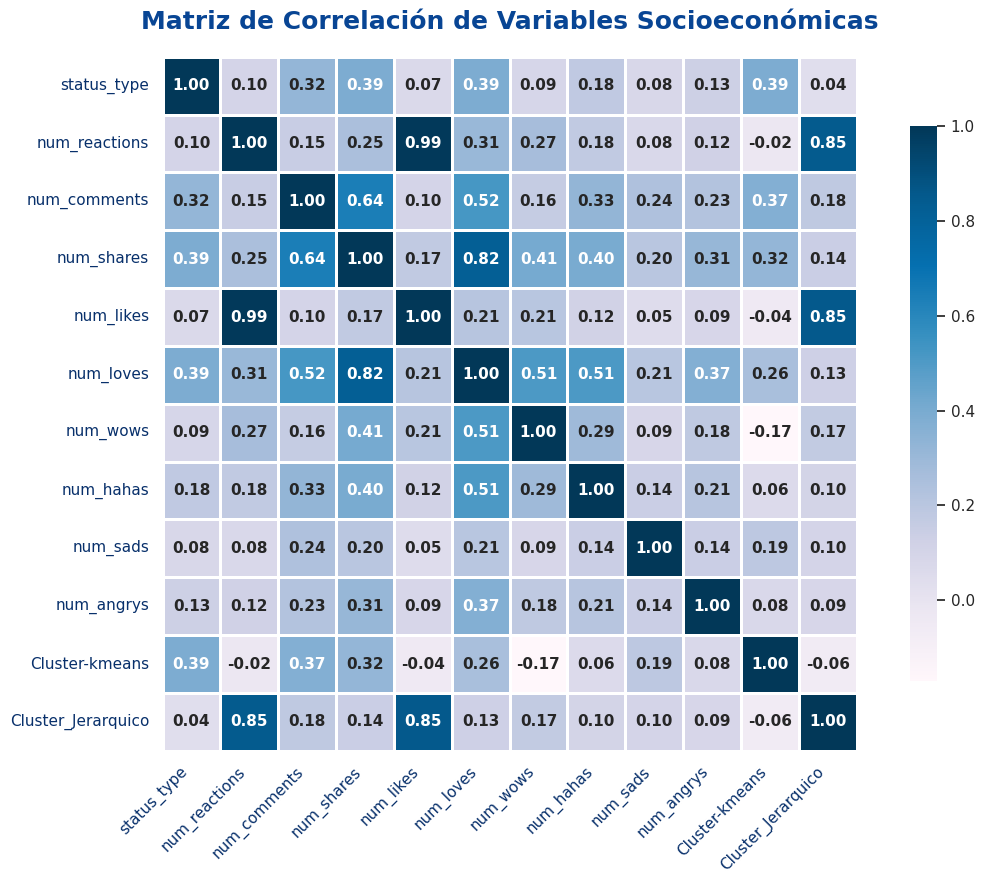

In [236]:
sns.set_theme(style="white")

corr_matrix = fb.corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix, 
    annot=True,                              
    cmap='PuBu',                            
    fmt=".2f",                               
    linewidths=1,                        
    linecolor='white',                    
    cbar_kws={"shrink": .8},                 
    square=True,                            
    annot_kws={"size": 11, "weight": "bold"} 
)

plt.title('Matriz de Correlación de Variables Socioeconómicas', 
        fontsize=18, fontweight='bold', color='#084594', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11, color='#08306b')
plt.yticks(fontsize=11, color='#08306b')

plt.tight_layout()
plt.show()

Como hay correlaciones relativamente altas por ejemplo entre num_shares, num_hahas , podría aplicarse pca, entonces primero hago una copia del df y un hago un drop de los clusters para que no pùeda afectar.

In [237]:
fb2 = fb
fb2.drop(columns=['Cluster-kmeans', 'Cluster_Jerarquico'], inplace=True)

In [238]:

X_scaled2 = scaler.fit_transform(fb2)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled2)

ahora con la reducción procedo a volver buscar los valores de k óptimos

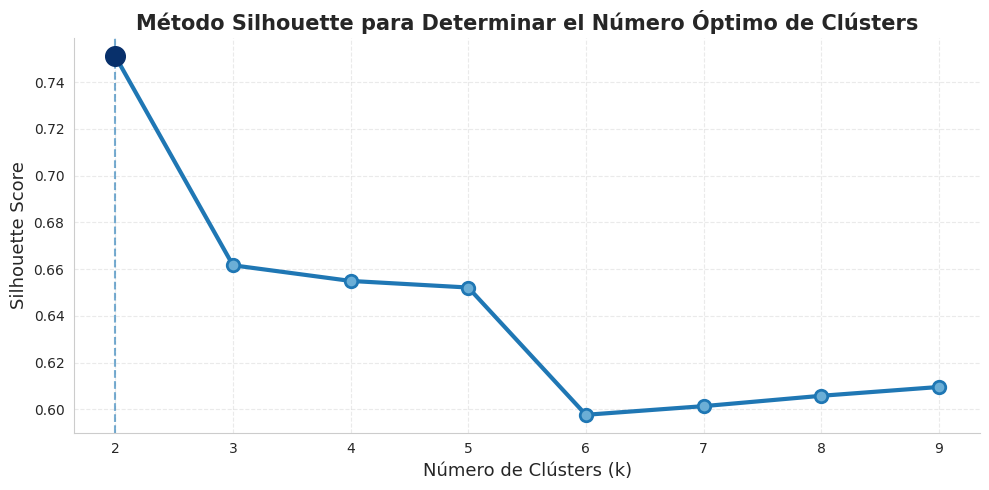

In [240]:
sns.set_style("whitegrid")

scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_pca)
    score = silhouette_score(X_pca, kmeans.labels_, metric='euclidean')
    scores.append(score)

scores = np.array(scores)

best_k = list(K_range)[scores.argmax()]
best_score = scores.max()

plt.figure(figsize=(10,5))

blue_main = "#1f77b4"
blue_light = "#6baed6"

plt.plot(
    list(K_range),
    scores,
    marker='o',
    markersize=9,
    linewidth=3,
    color=blue_main,
    markerfacecolor=blue_light,
    markeredgewidth=2
)

#esto es para resaltar el mejor k
plt.scatter(best_k, best_score, s=200, color="#08306b", zorder=3)
plt.axvline(best_k, linestyle="--", alpha=0.6)

plt.xlabel("Número de Clústers (k)", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=13)
plt.title("Método Silhouette para Determinar el Número Óptimo de Clústers", fontsize=15, weight="bold")

plt.xticks(list(K_range))
plt.grid(True, linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

Al aplicar PCA , sigue saliendo el mismo valor de k por lo tanto tomaré el k = 3 para este dataset, porque el valor k = 2 es muy bajo, además en el dendrogama se podía ver que podría ser el valor de k = 3 

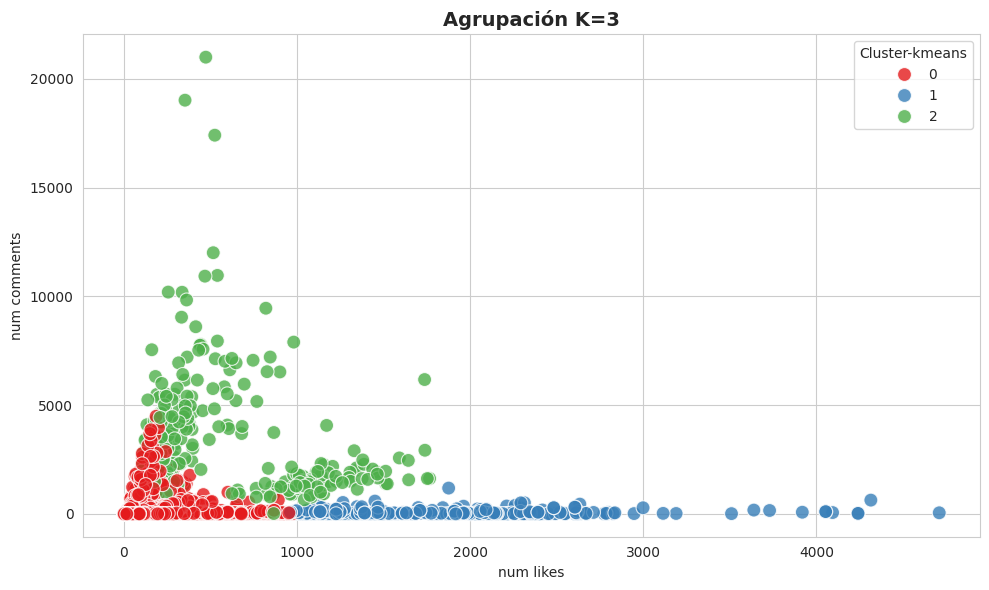

In [247]:
kmeans_definitivo = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_definitivo.fit(X_scaled)

fb['Cluster-kmeans'] = kmeans_definitivo.labels_
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fb,
x='num_likes',
y='num_comments',
hue='Cluster-kmeans',
palette='Set1',
s=100,
alpha=0.8)
plt.title('Agrupación K=3', fontweight='bold', fontsize=14)
plt.xlabel('num likes')
plt.ylabel('num comments')
plt.tight_layout()
plt.show()

La agrupación de clústers quedaría de esta forma en función de los num_likes y num_comments